# NoC Architecture Generation

## 1. Check GPU Availability

In [1]:
# Check CUDA/GPU availability

import torch
print(f"\nPyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")


PyTorch version: 2.5.1+cu121
CUDA available: True
CUDA version: 12.1
GPU: NVIDIA GeForce RTX 4090 Laptop GPU
GPU Memory: 15.99 GB


## 2. Install Dependencies

In [3]:
# Install required packages
!pip install -q transformers==4.41.2
!pip install -q trl==0.8.6
!pip install -q accelerate==0.30.1
!pip install -q datasets==2.18.0
!pip install -q peft==0.11.1

In [4]:
!pip install -q bitsandbytes==0.46.1
%pip install -U pip setuptools wheel
%pip install sentencepiece
!pip install -q protobuf==4.25.3

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## 3. Download Data 
- `src/validate_architecture.py` - Validation module
- `data/processed_str/valid.jsonl` - Test data
- Trained model files 

## 4. Create Validation Module

In [7]:
%%writefile src/validate_architecture.py

"""NoC Architecture Validation Module"""
import json
from typing import Dict, List, Tuple

class ArchitectureValidator:
    """Validates NoC architecture constraints."""
    
    def __init__(self, spec: Dict, output: Dict):
        self.spec = spec
        self.output = output
        self.errors = []
        self.warnings = []
    
    def validate_all(self) -> Tuple[bool, Dict]:
        self.errors = []
        self.warnings = []
        
        self._validate_switch_placement()
        self._validate_path_elements()
        self._validate_route_connectivity()
        self._validate_no_cycles()
        
        is_valid = len(self.errors) == 0
        
        report = {
            "valid": is_valid,
            "errors": self.errors,
            "warnings": self.warnings,
            "checks": {
                "switch_placement": not self._has_error("switch_placement"),
                "path_elements": not self._has_error("path_elements"),
                "route_connectivity": not self._has_error("route_connectivity"),
                "no_cycles": not self._has_error("cycles")
            }
        }
        
        return is_valid, report
    
    def _has_error(self, error_type: str) -> bool:
        return any(error_type in e for e in self.errors)
    
    def _validate_switch_placement(self):
        floorplan = self.spec.get("floorplan_dim", [1000, 1000])
        max_x, max_y = floorplan[0], floorplan[1]
        blockages = self.spec.get("blockages", {})
        switches = self.output.get("switches", {})
        
        for switch_id, coords in switches.items():
            x, y = coords["x"], coords["y"]
            
            if not (0 <= x <= max_x and 0 <= y <= max_y):
                self.errors.append(
                    f"switch_placement: {switch_id} at ({x}, {y}) outside bounds ({max_x}, {max_y})"
                )
            
            for block_id, block in blockages.items():
                bx, by = block["x"], block["y"]
                bw, bh = block["width"], block["height"]
                
                if (bx <= x <= bx + bw) and (by <= y <= by + bh):
                    self.errors.append(
                        f"switch_placement: {switch_id} at ({x}, {y}) inside blockage {block_id}"
                    )
    
    def _validate_path_elements(self):
        inits = set(self.spec.get("inits", {}).keys())
        targets = set(self.spec.get("targets", {}).keys())
        switches = set(self.output.get("switches", {}).keys())
        
        all_valid_nodes = inits | targets | switches
        routing_paths = self.output.get("routing_paths", {})
        
        for route_id, path in routing_paths.items():
            if not isinstance(path, list):
                self.errors.append(f"path_elements: {route_id} path is not a list")
                continue
            
            for node in path:
                if node not in all_valid_nodes:
                    self.errors.append(
                        f"path_elements: {route_id} contains non-existent node '{node}'"
                    )
    
    def _validate_route_connectivity(self):
        connectivity = self.spec.get("connectivity", {})
        routing_paths = self.output.get("routing_paths", {})
        
        for route_id, (init, target) in connectivity.items():
            if route_id not in routing_paths:
                self.errors.append(
                    f"route_connectivity: Required route {route_id} ({init}->{target}) is missing"
                )
                continue
            
            path = routing_paths[route_id]
            
            if len(path) < 2:
                self.errors.append(
                    f"route_connectivity: {route_id} path too short"
                )
            elif path[0] != init:
                self.errors.append(
                    f"route_connectivity: {route_id} should start with {init}, got {path[0]}"
                )
            elif path[-1] != target:
                self.errors.append(
                    f"route_connectivity: {route_id} should end with {target}, got {path[-1]}"
                )
    
    def _validate_no_cycles(self):
        routing_paths = self.output.get("routing_paths", {})
        
        for route_id, path in routing_paths.items():
            if not isinstance(path, list) or len(path) < 2:
                continue
            
            seen_nodes = set()
            for node in path:
                if node in seen_nodes:
                    self.errors.append(
                        f"cycles: Route {route_id} contains loop - '{node}' appears multiple times"
                    )
                    break
                seen_nodes.add(node)

def validate_architecture(spec: Dict, output: Dict) -> Tuple[bool, Dict]:
    validator = ArchitectureValidator(spec, output)
    return validator.validate_all()

Overwriting src/validate_architecture.py


## 5. Load Test Data

In [9]:
import json

# Load validation dataset
test_samples = []
with open('test_part_3.jsonl', 'r') as f:
    for line in f:
        test_samples.append(json.loads(line))

print(f"Loaded {len(test_samples)} test samples")

# Show first sample structure
print("\nSample structure:")
print(f"Keys: {test_samples[0].keys()}")
print(f"Specs length: {len(test_samples[0]['spec'])} chars")

Loaded 2229 test samples

Sample structure:
Keys: dict_keys(['spec', 'switches', 'routing_paths', 'network'])
Specs length: 5 chars


## 6. Load Trained Model

In [13]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel
import torch

# Configuration
base_model_name = "mistralai/Mistral-7B-Instruct-v0.2"
adapter_path = "outputs/mistral7b-noc-switch-qlora"

# QLoRA config for inference
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(base_model_name)
tokenizer.pad_token = tokenizer.eos_token

print("Loading base model...")
model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

print("Loading LoRA adapter...")
model = PeftModel.from_pretrained(model, adapter_path)

print("\n✅ Model loaded successfully!")
print(f"Device: {next(model.parameters()).device}")

Loading tokenizer...
Loading base model...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loading LoRA adapter...

✅ Model loaded successfully!
Device: cuda:0


## 7. Generate and Validate Outputs

In [67]:
from src.validate_architecture import validate_architecture
import json
import re
import torch
import time

model.eval()

def create_user_prompt(spec):
    if isinstance(spec, dict):
        spec_str = json.dumps(spec, separators=(",", ":"))
    else:
        spec_str = str(spec)

    return f"""You are an expert NoC physical designer.

Given the specification below, return ONLY valid JSON.

Required output format:
{{
  "switches": {{
    "s_0": {{"x": 0, "y": 0}},
    "s_1": {{"x": 0, "y": 0}}
  }},
  "routing_paths": {{
    "r_0": ["i_0", "s_0", "t_0"],
    "r_1": ["i_1", "s_1", "t_1"]
  }}
}}

Rules:
- "switches" must be a JSON object, not a list.
- Each switch must be keyed by switch id like "s_0", "s_1".
- Each switch value must contain only "x" and "y".
- Do not include a "connections" field.
- "routing_paths" must be a JSON object keyed by route ids.
- Include all routes required by the connectivity field.
- Return JSON only. No explanations. No markdown.

Specification:
{spec_str}
"""
def generate_with_model(spec):
    user_prompt = create_user_prompt(spec)

    messages = [
        {"role": "user", "content": user_prompt}
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    print("Prompt built with chat template.")

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1024
    ).to(model.device)

    input_len = inputs["input_ids"].shape[1]
    print("Tokenized input.")
    print("Input tokens:", input_len)

    start = time.time()
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=512,
            do_sample=False,
            use_cache=True,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.05
        )
    print(f"Generation finished in {time.time() - start:.2f} seconds.")

    new_tokens = outputs[0][input_len:]
    generated_part = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

    print("Generated preview:")
    print(generated_part[:500])

    json_match = re.search(r'\{[\s\S]*\}', generated_part)
    if json_match:
        candidate = json_match.group(0)
    try:
        parsed = json.loads(candidate)
        return parsed, generated_part
    except json.JSONDecodeError as e:
        print("JSON decode error:", e)
        return None, generated_part

def validate_sample(sample, use_model=True):
    sample_id = sample.get("id", "unknown")

    try:
        spec = sample.get("spec", {})

        if use_model:
            print(f"Running model inference for sample: {sample_id}")
            output, raw_text = generate_with_model(spec)
            if output is None:
                return {
                    "valid": False,
                    "errors": ["Failed to parse JSON from model output"],
                    "checks": {},
                    "output": None,
                    "sample_id": sample_id,
                    "generated_text": raw_text
                }
        else:
            output = {
                "switches": sample.get("switches", {}),
                "routing_paths": sample.get("routing_paths", {})
            }
            raw_text = None

    except Exception as e:
        return {
            "valid": False,
            "errors": [f"Failed during generation/validation setup: {str(e)}"],
            "checks": {},
            "output": None,
            "sample_id": sample_id,
            "generated_text": None
        }

    is_valid, report = validate_architecture(spec, output)

    return {
        "valid": is_valid,
        "errors": report["errors"],
        "checks": report["checks"],
        "output": output,
        "sample_id": sample_id,
        "generated_text": raw_text
    }

print("Ready to validate samples!")
print(f"Model device: {next(model.parameters()).device}")
print(f"Model in eval mode: {not model.training}")

Ready to validate samples!
Model device: cuda:0
Model in eval mode: True


## 8. Run Validation on Sample

In [69]:
# Test on first sample using MODEL INFERENCE
print("Generating and validating sample 0 using the model...\n")

result = validate_sample(test_samples[0], use_model=True)

print("="*60)
print("VALIDATION RESULT")
print("="*60)
print(f"Valid: {result['valid']}")

if result.get('sample_id') is not None:
    print(f"Sample ID: {result['sample_id']}")

print(f"\nChecks:")
for check_name, passed in result.get('checks', {}).items():
    status = "✅" if passed else "❌"
    print(f"  {status} {check_name}")

if result['errors']:
    print(f"\nErrors ({len(result['errors'])}):")
    for error in result['errors'][:5]:
        print(f"  - {error}")

if result['output'] is not None:
    print(f"\nGenerated Output:")
    print(f"  Switches: {len(result['output'].get('switches', {}))}")
    print(f"  Routing Paths: {len(result['output'].get('routing_paths', {}))}")
else:
    print("\nFailed to parse output as JSON")
    if result.get('generated_text'):
        print("Generated text preview:")
        print(result['generated_text'][:500])

Generating and validating sample 0 using the model...

Running model inference for sample: unknown
Prompt built with chat template.
Tokenized input.
Input tokens: 825
Generation finished in 88.25 seconds.
Generated preview:
{
  "switches": {
    "s_0": {"x": 939, "y": 154},
    "s_1": {"x": 937, "y": 540}
  },
  "routing_paths": {
    "r_0": ["i_0", "s_0", "t_2"],
    "r_1": ["i_0", "s_0", "t_1"],
    "r_2": ["i_0", "s_0", "t_4"],
    "r_3": ["i_0", "s_0", "t_0"],
    "r_4": ["i_1", "s_1", "t_3"],
    "r_5": ["i_1", "s_1", "t_1"],
    "r_6": ["i_1", "s_1", "t_4"],
    "r_7": ["i_2", "s_0", "t_3"],
    "r_8": ["i_2", "s_0", "t_0"],
    "r_9": ["i_2", "s_0", "t_2"],
    "r_10": ["i_3", "s_1", "t_1"],
    "r_11": ["i_
VALIDATION RESULT
Valid: True
Sample ID: unknown

Checks:
  ✅ switch_placement
  ✅ path_elements
  ✅ route_connectivity
  ✅ no_cycles

Generated Output:
  Switches: 2
  Routing Paths: 18


## 9. Batch Validation

In [71]:
# Validate multiple samples using MODEL INFERENCE
num_samples = min(50, len(test_samples))

print(f"Generating and validating {num_samples} samples using model inference...\n")

results = []
for i in range(num_samples):
    print(f"\nSample {i+1}/{num_samples}...")
    result = validate_sample(test_samples[i], use_model=True)
    results.append(result)
    print("✅ Valid" if result['valid'] else "❌ Invalid")

valid_count = sum(1 for r in results if r['valid'])
invalid_count = len(results) - valid_count
validity_rate = 100 * valid_count / len(results)

print("\n" + "="*60)
print("VALIDATION SUMMARY")
print("="*60)
print(f"Total Samples: {len(results)}")
print(f"Valid: {valid_count} ({validity_rate:.1f}%)")
print(f"Invalid: {invalid_count}")

all_errors = []
for r in results:
    all_errors.extend(r['errors'])

if all_errors:
    print(f"\nTotal Errors: {len(all_errors)}")
    print("\nMost Common Errors:")
    error_types = {}
    for error in all_errors:
        error_type = error.split(':')[0]
        error_types[error_type] = error_types.get(error_type, 0) + 1

    for error_type, count in sorted(error_types.items(), key=lambda x: x[1], reverse=True):
        print(f"  {error_type}: {count}")

Generating and validating 50 samples using model inference...


Sample 1/50...
Running model inference for sample: unknown
Prompt built with chat template.
Tokenized input.
Input tokens: 825
Generation finished in 83.64 seconds.
Generated preview:
{
  "switches": {
    "s_0": {"x": 939, "y": 154},
    "s_1": {"x": 937, "y": 540}
  },
  "routing_paths": {
    "r_0": ["i_0", "s_0", "t_2"],
    "r_1": ["i_0", "s_0", "t_1"],
    "r_2": ["i_0", "s_0", "t_4"],
    "r_3": ["i_0", "s_0", "t_0"],
    "r_4": ["i_1", "s_1", "t_3"],
    "r_5": ["i_1", "s_1", "t_1"],
    "r_6": ["i_1", "s_1", "t_4"],
    "r_7": ["i_2", "s_0", "t_3"],
    "r_8": ["i_2", "s_0", "t_0"],
    "r_9": ["i_2", "s_0", "t_2"],
    "r_10": ["i_3", "s_1", "t_1"],
    "r_11": ["i_
✅ Valid

Sample 2/50...
Running model inference for sample: unknown
Prompt built with chat template.
Tokenized input.
Input tokens: 685
Generation finished in 37.39 seconds.
Generated preview:
{
  "switches": {
    "s_0": {"x": 510, "y": 26},
    "s_1

## 10. Detailed Analysis

In [73]:
# Analyse validation checks
check_stats = {
    'switch_placement': 0,
    'path_elements': 0,
    'route_connectivity': 0,
    'no_cycles': 0
}

for result in results:
    for check_name, passed in result.get('checks', {}).items():
        if passed:
            check_stats[check_name] += 1

print("Constraint Pass Rates:")
for check_name, count in check_stats.items():
    rate = 100 * count / len(results)
    print(f"  {check_name}: {count}/{len(results)} ({rate:.1f}%)")

Constraint Pass Rates:
  switch_placement: 35/50 (70.0%)
  path_elements: 35/50 (70.0%)
  route_connectivity: 14/50 (28.0%)
  no_cycles: 35/50 (70.0%)


## 11. Visualise Results

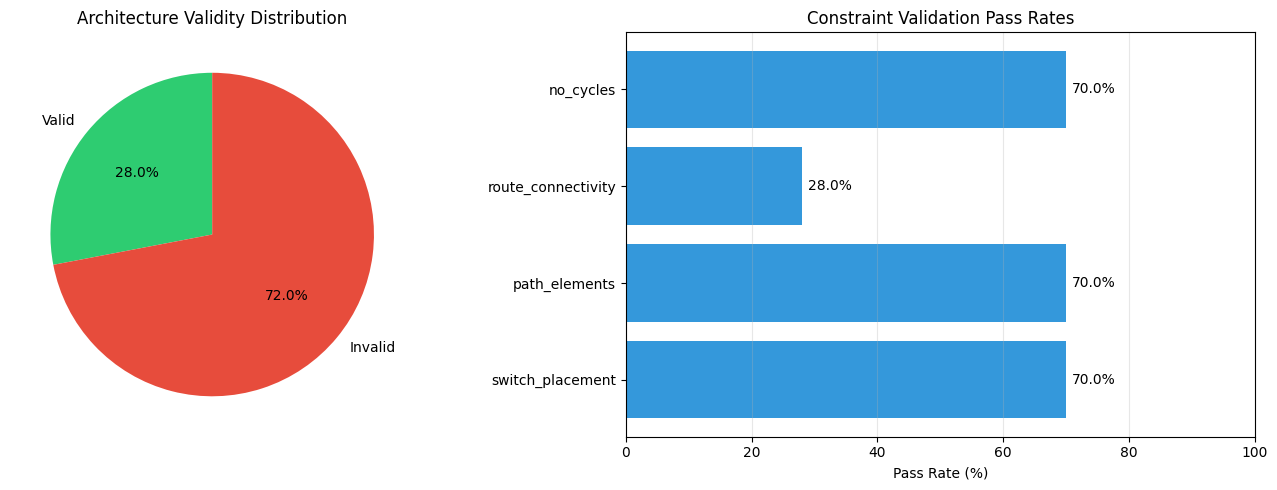

In [75]:
import matplotlib.pyplot as plt

# Validity pie chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Validity distribution
ax1.pie(
    [valid_count, invalid_count],
    labels=['Valid', 'Invalid'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90
)
ax1.set_title('Architecture Validity Distribution')

# Constraint pass rates
checks = list(check_stats.keys())
pass_rates = [100 * check_stats[c] / len(results) for c in checks]

ax2.barh(checks, pass_rates, color='#3498db')
ax2.set_xlabel('Pass Rate (%)')
ax2.set_title('Constraint Validation Pass Rates')
ax2.set_xlim(0, 100)
ax2.grid(axis='x', alpha=0.3)

for i, v in enumerate(pass_rates):
    ax2.text(v + 1, i, f'{v:.1f}%', va='center')

plt.tight_layout()
plt.show()

## 12. Compare with Ground Truth

In [87]:
# Compare generated outputs with ground truth
print("Comparing Model-Generated vs Ground Truth:\n")

print(f"Analyzed {len(results)} test samples\n")

for i in range(min(50, len(results))):
    sample = test_samples[i]
    result = results[i]
    
    # Extract ground truth from label
    gt_output = {
         "switches": sample.get("switches", {}),
         "routing_paths": sample.get("routing_paths", {})}
    gen_output = result.get('output', {})
    
    print(f"Sample {i} ({result['sample_id']}):")
    print(f"  Ground Truth - Switches: {len(gt_output.get('switches', {}))}, Routes: {len(gt_output.get('routing_paths', {}))}")
    print(f"  Generated    - Switches: {len(gen_output.get('switches', {})) if gen_output else 'N/A'}, Routes: {len(gen_output.get('routing_paths', {})) if gen_output else 'N/A'}")
    print(f"  Validation: {'✅ Valid' if result['valid'] else '❌ Invalid'}")
    if result['errors']:
        print(f"  Errors: {len(result['errors'])} found")
    print()

Comparing Model-Generated vs Ground Truth:

Analyzed 50 test samples

Sample 0 (unknown):
  Ground Truth - Switches: 7, Routes: 18
  Generated    - Switches: 2, Routes: 18
  Validation: ✅ Valid

Sample 1 (unknown):
  Ground Truth - Switches: 6, Routes: 10
  Generated    - Switches: 2, Routes: 6
  Validation: ❌ Invalid
  Errors: 4 found

Sample 2 (unknown):
  Ground Truth - Switches: 7, Routes: 24
  Generated    - Switches: N/A, Routes: N/A
  Validation: ❌ Invalid
  Errors: 1 found

Sample 3 (unknown):
  Ground Truth - Switches: 6, Routes: 15
  Generated    - Switches: 2, Routes: 15
  Validation: ✅ Valid

Sample 4 (unknown):
  Ground Truth - Switches: 9, Routes: 24
  Generated    - Switches: N/A, Routes: N/A
  Validation: ❌ Invalid
  Errors: 1 found

Sample 5 (unknown):
  Ground Truth - Switches: 8, Routes: 18
  Generated    - Switches: 2, Routes: 18
  Validation: ✅ Valid

Sample 6 (unknown):
  Ground Truth - Switches: 6, Routes: 20
  Generated    - Switches: N/A, Routes: N/A
  Validati